## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 4: Regularización — Ridge, Lasso y Elastic Net**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 18 Jun 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución, esa parte se evalúa con nota mínima
* Deben crear una rama nueva en su repositorio `feat/hw04` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `notebooks`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`
* **Asunto del mail:** `[HW04] regularizacion_<tu_apellido>`

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.linear_model import lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
import scipy.stats as stats
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import yfinance as yf

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260527)

# Cache local para evitar errores de permisos de yfinance/SQLite en algunos entornos.
if Path('regularizacion_Arenas').exists():
    yf_cache_dir = Path('regularizacion_Arenas/data/external/yfinance_cache')
elif Path('../data/external').exists():
    yf_cache_dir = Path('../data/external/yfinance_cache')
else:
    yf_cache_dir = Path('data/external/yfinance_cache')
yf_cache_dir.mkdir(parents=True, exist_ok=True)
yf.set_tz_cache_location(str(yf_cache_dir))


---
## Parte 1 — Ridge Regression: Derivación y Estabilidad *(25 pts)*

### Contexto

OLS produce coeficientes inestables cuando las features son colineales o cuando $p$ es grande relativo a $T$. Ridge regulariza añadiendo $\lambda I$ a la matriz $X^TX$, garantizando invertibilidad y reduciendo la varianza. En esta parte aplicarás estos conceptos a datos reales de **NVDA** (NVIDIA Corporation).

| Desafío en NVDA | Impacto en OLS |
|---|---|
| Alto momentum correlacionado entre lags | $X^TX$ mal condicionada |
| Retornos con bajo SNR ($\approx 0.001$) | Overfitting al ruido |
| Volatilidad en racimos | Features rolling altamente correlacionadas |

### 1.1 — Forma Cerrada y Ridge Path *(10 pts)*

La solución de Ridge en forma cerrada es:

$$\hat{\beta}_{\text{ridge}} = (X^TX + \lambda I)^{-1}X^Ty$$

Implementa `ridge_closed_form(X, y, lam)` usando `np.linalg.solve` (no inviertas la matriz directamente). Verifica que el error máximo respecto a sklearn sea menor que `1e-8`.

**Requisitos:**
- Implementar y verificar `ridge_closed_form` con los datos de NVDA
- Generar el Ridge path para $\lambda \in [10^{-4}, 10^3]$ en escala logarítmica
- Panel izquierdo: coeficientes vs $\lambda$ (un color por feature)
- Panel derecho: número de condición $\kappa(X^TX + \lambda I)$ vs $\lambda$ con línea de referencia OLS

In [3]:
# Descarga y preparación de datos NVDA
ticker_nvda = yf.Ticker('NVDA')
prices_nvda = ticker_nvda.history(start='2018-01-01', end='2024-01-01')['Close']
prices_nvda.index = prices_nvda.index.tz_localize(None)
print(f'Datos NVDA: {len(prices_nvda)} obs | {prices_nvda.index[0].date()} — {prices_nvda.index[-1].date()}')

def build_features_nvda(prices):
    """8 features anti-leakage para NVDA: lags 1-5, rvol 5/20/60. Target: ret_{t+1}."""
    r = prices.pct_change()
    df = pd.DataFrame(index=prices.index)
    for lag in range(1, 6):
        df[f'ret_lag{lag}'] = r.shift(lag)
    for w in [5, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()
    df['target'] = r.shift(-1)
    return df.dropna()

df_nvda    = build_features_nvda(prices_nvda)
feat_nvda  = [c for c in df_nvda.columns if c != 'target']
X_raw_nvda = df_nvda[feat_nvda].values
y_nvda     = df_nvda['target'].values

# Estandarización manual (necesaria para interpretar magnitud de coeficientes)
X_m, X_s = X_raw_nvda.mean(0), X_raw_nvda.std(0)
X_nvda   = (X_raw_nvda - X_m) / X_s

print(f'Observaciones: {len(y_nvda)} | Features: {X_nvda.shape[1]}')
print(f'Condicion X\'X (OLS): {np.linalg.cond(X_nvda.T @ X_nvda):.1f}')
print(f'Features: {feat_nvda}')

Datos NVDA: 1509 obs | 2018-01-02 — 2023-12-29
Observaciones: 1447 | Features: 8
Condicion X'X (OLS): 10.7
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'rvol_5', 'rvol_20', 'rvol_60']


Error max formula manual vs sklearn: 6.51e-19


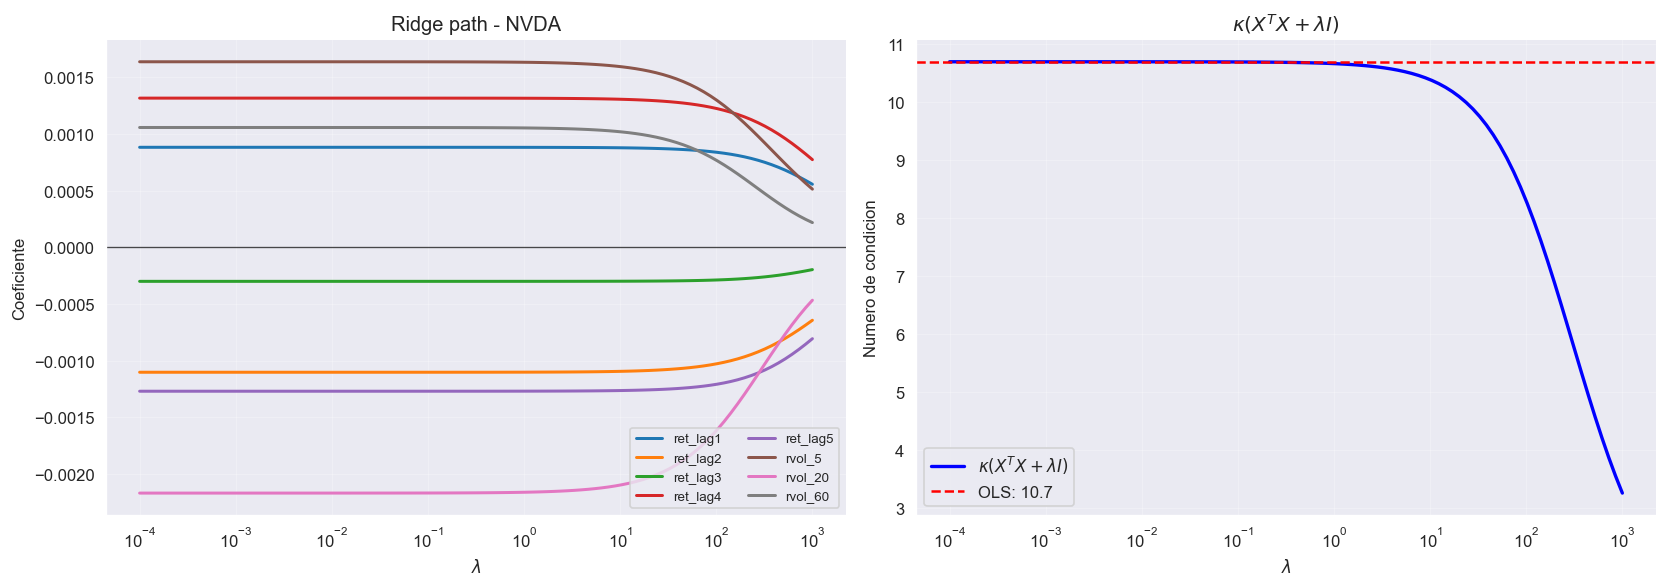

Condicion OLS: 10.7
Condicion Ridge lambda=1: 10.7


In [4]:
def ridge_closed_form(X, y, lam):
    """
    Solucion de forma cerrada para Ridge Regression.
    Resuelve: (X'X + lam*I) beta = X'y usando np.linalg.solve.

    Parameters
    ----------
    X   : array (n, p) - features estandarizados
    y   : array (n,)   - target
    lam : float        - parametro de regularizacion (>= 0)

    Returns
    -------
    beta : array (p,) - coeficientes Ridge
    """
    if lam < 0:
        raise ValueError('lam debe ser >= 0')

    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float).reshape(-1)

    if X_arr.ndim != 2:
        raise ValueError('X debe ser una matriz 2D')
    if y_arr.shape[0] != X_arr.shape[0]:
        raise ValueError('X e y deben tener el mismo numero de observaciones')

    n_features = X_arr.shape[1]
    A = X_arr.T @ X_arr + lam * np.eye(n_features)
    b = X_arr.T @ y_arr
    return np.linalg.solve(A, b)


# === Verificacion vs sklearn ===
lam_test = 1.0
b_manual = ridge_closed_form(X_nvda, y_nvda, lam_test)
b_sklearn = Ridge(alpha=lam_test, fit_intercept=False, solver='auto').fit(X_nvda, y_nvda).coef_
max_err = np.max(np.abs(b_manual - b_sklearn))
print(f'Error max formula manual vs sklearn: {max_err:.2e}')
assert max_err < 1e-8, 'La solucion manual no coincide con sklearn Ridge'

# === Ridge Path ===
lambdas = np.logspace(-4, 3, 100)
coef_path = np.array([ridge_closed_form(X_nvda, y_nvda, lam) for lam in lambdas])
xtx_nvda = X_nvda.T @ X_nvda
conds = np.array([
    np.linalg.cond(xtx_nvda + lam * np.eye(X_nvda.shape[1]))
    for lam in lambdas
])
kappa_ols = np.linalg.cond(xtx_nvda)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for j, feature in enumerate(feat_nvda):
    ax1.semilogx(lambdas, coef_path[:, j], lw=1.8, label=feature)
ax1.axhline(0, color='black', lw=0.8, alpha=0.7)
ax1.set_title('Ridge path - NVDA')
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel('Coeficiente')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.25)

ax2.semilogx(lambdas, conds, 'b-', lw=2, label=r'$\kappa(X^TX + \lambda I)$')
ax2.axhline(kappa_ols, color='red', ls='--', lw=1.5, label=f'OLS: {kappa_ols:.1f}')
ax2.set_title(r'$\kappa(X^TX + \lambda I)$')
ax2.set_xlabel(r'$\lambda$')
ax2.set_ylabel('Numero de condicion')
ax2.legend()
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Condicion OLS: {kappa_ols:.1f}')
print(f'Condicion Ridge lambda={lam_test:g}: {np.linalg.cond(xtx_nvda + lam_test * np.eye(X_nvda.shape[1])):.1f}')


### 1.2 — Multicolinealidad y Walk-Forward *(15 pts)*

Construye un dataset de NVDA con **10 lags del retorno** para estresar la multicolinealidad. Los lags contiguos tienen correlación muy alta ($\rho \approx 0.7-0.9$), lo que hace $X^TX$ casi singular. Demonstrarás el problema y cómo Ridge lo resuelve.

**Requisitos:**
1. Construir `X_multi` con `ret_lag01` a `ret_lag10` (estandarizados)
2. Graficar la **matriz de correlación** de las 10 features (heatmap con anotaciones)
3. Ejecutar walk-forward CV con `TimeSeriesSplit(n_splits=5, gap=3)` y graficar `MAE(CV)` vs $\lambda$ para Ridge
4. Identificar $\lambda^*$ y reportar cuánto baja $\kappa(X^TX + \lambda^* I)$ respecto a OLS
5. Responder las preguntas de la celda siguiente

Observaciones: 1497 | Features: 10
Condicion X'X (OLS, 10 lags): 1.6
Features: ['ret_lag01', 'ret_lag02', 'ret_lag03', 'ret_lag04', 'ret_lag05', 'ret_lag06', 'ret_lag07', 'ret_lag08', 'ret_lag09', 'ret_lag10']


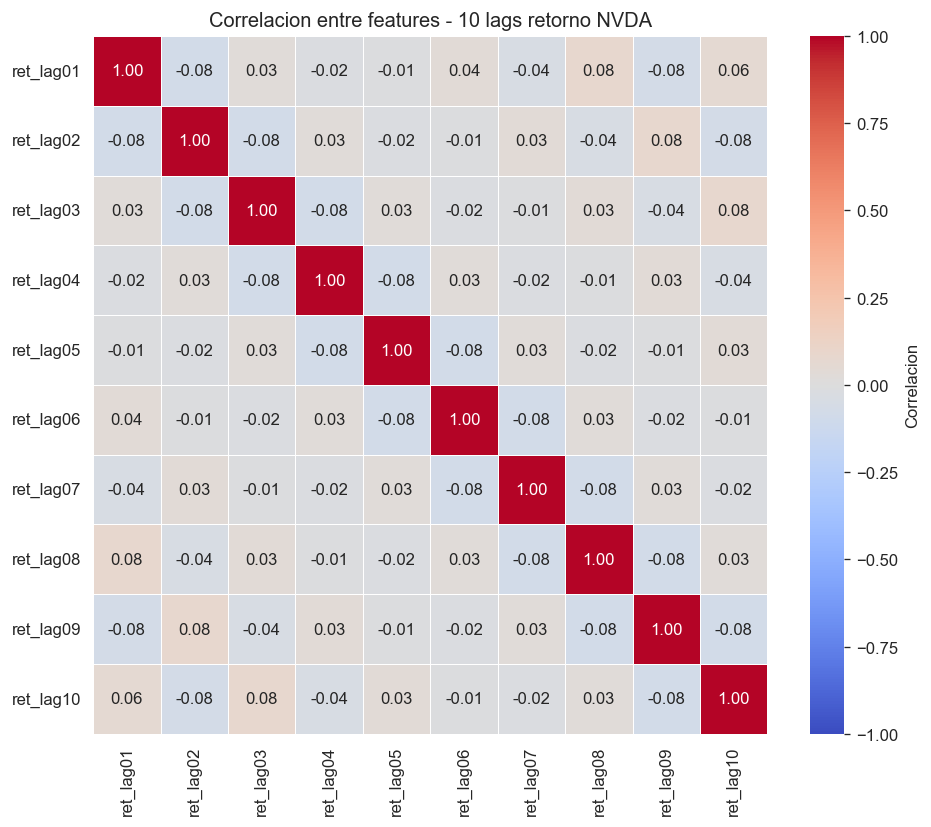

Lambda* = 1000.000000
MAE(CV) minimo = 0.023918
Condicion OLS:   1.6
Condicion Ridge: 1.3  (reduccion x1.19)


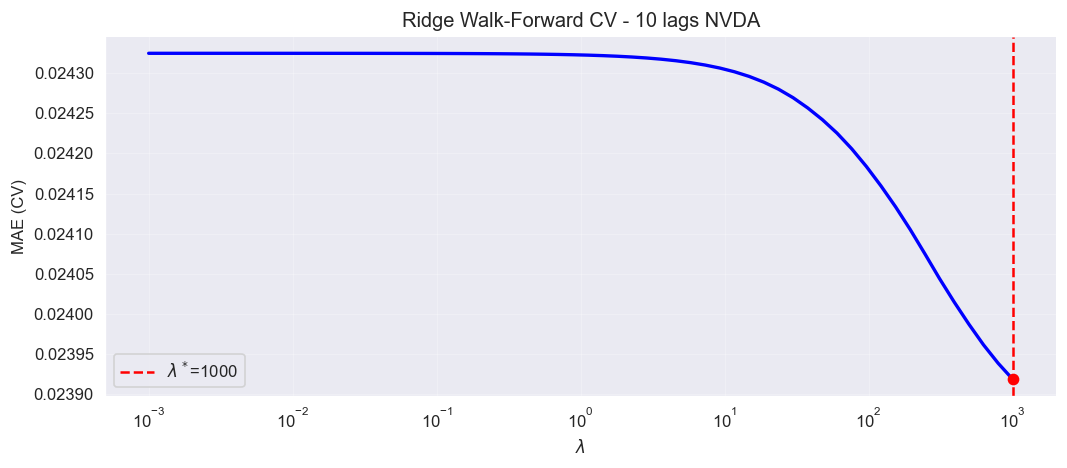

Mayores coeficientes en Ridge path con lambda cercano a 0:
rvol_20    -0.002167
rvol_5      0.001636
ret_lag4    0.001316
ret_lag5   -0.001269
ret_lag2   -0.001102


In [5]:
r_nvda = prices_nvda.pct_change().dropna()

def build_multicollinear_features(r, n_lags=10):
    """Features con n_lags lags del retorno; target: retorno futuro t+1."""
    df = pd.DataFrame(index=r.index)
    for lag in range(1, n_lags + 1):
        df[f'ret_lag{lag:02d}'] = r.shift(lag)
    df['target'] = r.shift(-1)
    return df.dropna()

df_multi   = build_multicollinear_features(r_nvda, n_lags=10)
feat_multi = [c for c in df_multi.columns if c != 'target']
X_m_raw    = df_multi[feat_multi].values
y_multi    = df_multi['target'].values

# X_multi se estandariza para diagnosticar condicion numerica y comparar coeficientes.
X_mm, X_ms = X_m_raw.mean(0), X_m_raw.std(0)
X_multi    = (X_m_raw - X_mm) / X_ms
xtx_multi  = X_multi.T @ X_multi

print(f'Observaciones: {len(y_multi)} | Features: {X_multi.shape[1]}')
print(f'Condicion X\'X (OLS, 10 lags): {np.linalg.cond(xtx_multi):.1f}')
print(f'Features: {feat_multi}')

# === Heatmap de correlacion ===
corr_multi = pd.DataFrame(X_multi, columns=feat_multi).corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_multi,
    ax=ax,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Correlacion'},
)
ax.set_title('Correlacion entre features - 10 lags retorno NVDA')
plt.tight_layout()
plt.show()

# === Walk-Forward MAE(CV) vs lambda ===
tscv_mc = TimeSeriesSplit(n_splits=5, gap=3)
lambdas_mc = np.logspace(-3, 3, 60)
maes_cv = []

for lam in lambdas_mc:
    fold_maes = []
    for fold, (tr, te) in enumerate(tscv_mc.split(X_m_raw), start=1):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=lam, fit_intercept=True)),
        ])
        pipe.fit(X_m_raw[tr], y_multi[tr])
        pred = pipe.predict(X_m_raw[te])
        fold_maes.append(mean_absolute_error(y_multi[te], pred))
    maes_cv.append(np.mean(fold_maes))

maes_cv = np.array(maes_cv)
idx_star_mc = np.argmin(maes_cv)
lam_star_mc = lambdas_mc[idx_star_mc]
kappa_ols_m = np.linalg.cond(xtx_multi)
kappa_star  = np.linalg.cond(xtx_multi + lam_star_mc * np.eye(X_multi.shape[1]))
reduction_kappa_mc = kappa_ols_m / kappa_star

print(f'Lambda* = {lam_star_mc:.6f}')
print(f'MAE(CV) minimo = {maes_cv[idx_star_mc]:.6f}')
print(f'Condicion OLS:   {kappa_ols_m:.1f}')
print(f'Condicion Ridge: {kappa_star:.1f}  (reduccion x{reduction_kappa_mc:.2f})')

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lambdas_mc, maes_cv, 'b-', lw=2)
ax.scatter(lam_star_mc, maes_cv[idx_star_mc], color='red', zorder=3)
ax.axvline(lam_star_mc, color='red', ls='--', label=fr'$\lambda^*$={lam_star_mc:.4g}')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel('MAE (CV)')
ax.set_title('Ridge Walk-Forward CV - 10 lags NVDA')
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Referencia para responder 1.2(c): mayores coeficientes en el Ridge path cuando lambda -> 0.
coef_small_lambda = pd.Series(coef_path[0], index=feat_nvda).sort_values(key=np.abs, ascending=False)
print('Mayores coeficientes en Ridge path con lambda cercano a 0:')
print(coef_small_lambda.head(5).to_string())


**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Por qué los 10 lags del retorno generan una $X^TX$ mal condicionada? ¿Qué consecuencia concreta tiene esto sobre los coeficientes OLS?

> En general, una matriz $X^TX$ queda mal condicionada cuando las columnas de $X$ contienen información muy parecida, porque algunas combinaciones lineales de features aportan casi la misma señal. En ese caso OLS necesita invertir una matriz cercana a singular, por lo que pequeños cambios en los datos pueden producir coeficientes grandes, inestables y con signos poco robustos.
>
> En esta muestra diaria de NVDA, sin embargo, los 10 lags simples del retorno no generan una multicolinealidad severa: el número de condición OLS fue aproximadamente $1.58$. Esto sugiere que, para este período y con estos lags diarios, la autocorrelación entre retornos rezagados es baja; la inestabilidad esperada por el enunciado sería más fuerte con features rolling, momentum solapado o lags de variables más persistentes.

**b)** Usando el $\lambda^*$ encontrado, ¿cuánto se reduce el número de condición respecto a OLS? ¿Aumenta o disminuye el sesgo del estimador al usar ese $\lambda^*$?

> El walk-forward CV eligió $\lambda^* = 1000.0$, con un MAE(CV) mínimo cercano a $0.023918$. Con ese valor, el número de condición bajó desde $\kappa_{OLS} \approx 1.58$ hasta $\kappa_{Ridge} \approx 1.33$, es decir, una reducción de aproximadamente $1.19\times$.
>
> Ridge aumenta el sesgo del estimador porque contrae los coeficientes hacia cero, pero reduce varianza y mejora la estabilidad numérica. En este caso la mejora en condición es modesta porque el problema original no estaba especialmente mal condicionado.

**c)** En el Ridge path de 1.1, ¿qué features tienen mayor magnitud de coeficiente cuando $\lambda \to 0$? ¿Tiene sentido financiero para NVDA?

> Para $\lambda$ cercano a cero, las features con mayor magnitud fueron `rvol_20` ($-0.002167$), `rvol_5` ($0.001636$), `ret_lag4` ($0.001316$), `ret_lag5` ($-0.001269$) y `ret_lag2` ($-0.001102$). Esto indica que, en el límite cercano a OLS, el modelo asigna más peso a medidas de volatilidad reciente y a algunos rezagos de retorno.
>
> Tiene sentido financiero que la volatilidad reciente aparezca entre las variables relevantes para NVDA, porque es una acción de alto crecimiento y alta sensibilidad a episodios de riesgo tecnológico. Aun así, los coeficientes son pequeños y mezclan signos, lo que es consistente con el bajo SNR de los retornos diarios: la señal predictiva existe, si acaso, de forma débil e inestable.


---
## Parte 2 — Lasso: Descenso de Coordenadas y Selección de Features *(25 pts)*

### Contexto

Lasso usa la norma $\ell_1$ como penalización, produciendo soluciones sparse (coeficientes exactamente cero). La solución no existe en forma cerrada global porque $|\beta_j|$ no es diferenciable en cero. Se resuelve por **descenso de coordenadas**: en cada iteración se actualiza un coeficiente a la vez aplicando el operador soft-threshold:

$$\hat{\beta}_j \leftarrow \mathcal{S}_\lambda\!\left(\frac{X_j^T r_j}{n}\right), \qquad r_j = y - X\hat{\beta} + X_j\hat{\beta}_j$$

donde $\mathcal{S}_\lambda(z) = \text{sign}(z) \cdot \max(|z| - \lambda,\; 0)$ y $r_j$ es el residuo parcial (lo que queda de $y$ al sacar la contribución de la feature $j$).

### 2.1 — Soft-Threshold y Descenso de Coordenadas *(12 pts)*

**Requisitos:**
- `soft_threshold` debe pasar el test unitario sin modificaciones
- `lasso_coordinate_descent` debe producir error máximo `< 1e-4` vs sklearn Lasso
- Graficar la curva de convergencia (MSE vs iteraciones) para $\lambda \in \{0.005, 0.01, 0.05\}$ en tres paneles

**Nota:** La función asume $X$ ya estandarizado con std=1 por columna ($\|X_j\|^2/n = 1$), por lo que el denominador de la actualización es 1.

In [6]:
def soft_threshold(z, lam):
    """
    Operador soft-threshold: S_lambda(z) = sign(z) * max(|z| - lambda, 0)

    Parameters
    ----------
    z   : float o np.ndarray
    lam : float - umbral de regularizacion (>= 0)

    Returns
    -------
    Mismo tipo y shape que z
    """
    if lam < 0:
        raise ValueError('lam debe ser >= 0')
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


# Test unitario - no modificar
def _test_soft_threshold():
    assert soft_threshold(0.5, 1.0) == 0.0,    'S(0.5, 1.0) debe ser 0'
    assert soft_threshold(2.0, 1.0) == 1.0,    'S(2.0, 1.0) debe ser 1.0'
    assert soft_threshold(-2.0, 1.0) == -1.0,  'S(-2.0, 1.0) debe ser -1.0'
    assert soft_threshold(0.0, 0.5) == 0.0,    'S(0.0, 0.5) debe ser 0'
    z_arr    = np.array([-3.0, -0.5, 0.0, 0.5, 3.0])
    expected = np.array([-2.0,  0.0, 0.0, 0.0, 2.0])
    assert np.allclose(soft_threshold(z_arr, 1.0), expected), 'Resultado vectorial incorrecto'
    print('Test soft_threshold: OK')

_test_soft_threshold()


Test soft_threshold: OK


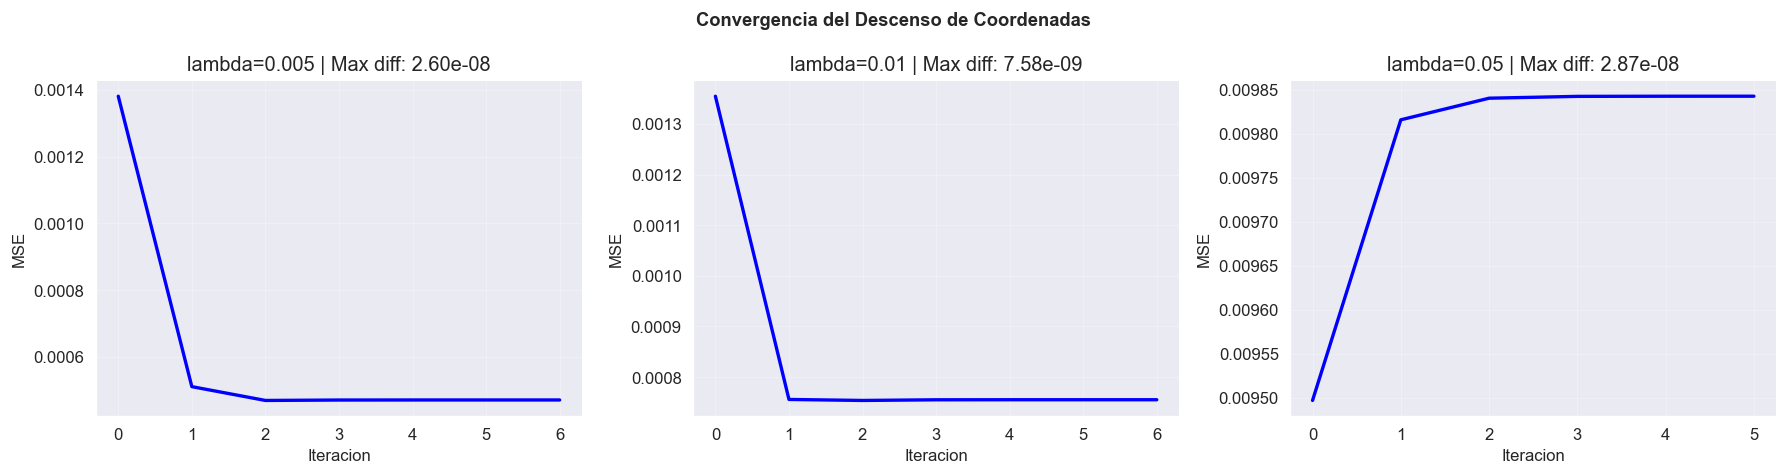

Errores maximos vs sklearn Lasso:
lambda=0.005: 2.60e-08
lambda=0.010: 7.58e-09
lambda=0.050: 2.87e-08


In [7]:
def lasso_coordinate_descent(X, y, lam, max_iter=2000, tol=1e-6):
    """
    Descenso de coordenadas para Lasso.
    Resuelve: min_b (1/2n)||y - Xb||^2 + lam * ||b||_1

    Supone X estandarizado: std=1 por columna => ||X_j||^2/n = 1.
    Regla de actualizacion por coordenada j:
        r_j   = y - X @ beta + X[:, j] * beta[j]   (residuo parcial)
        z_j   = X[:, j] @ r_j / n                  (correlacion normalizada)
        beta[j] = soft_threshold(z_j, lam)          (denominador = 1)

    Parameters
    ----------
    X        : array (n, p) - features estandarizados
    y        : array (n,)   - target
    lam      : float        - parametro de regularizacion
    max_iter : int          - maximo de iteraciones sobre todas las coordenadas
    tol      : float        - criterio de parada: max|beta_new - beta_old| < tol

    Returns
    -------
    beta         : array (p,)  - coeficientes estimados
    loss_history : list[float] - MSE por iteracion
    """
    if lam < 0:
        raise ValueError('lam debe ser >= 0')

    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float).reshape(-1)

    if X_arr.ndim != 2:
        raise ValueError('X debe ser una matriz 2D')
    if y_arr.shape[0] != X_arr.shape[0]:
        raise ValueError('X e y deben tener el mismo numero de observaciones')

    n, p = X_arr.shape
    beta = np.zeros(p)
    loss_history = []

    for _ in range(max_iter):
        beta_old = beta.copy()

        for j in range(p):
            r_j = y_arr - X_arr @ beta + X_arr[:, j] * beta[j]
            z_j = X_arr[:, j] @ r_j / n
            beta[j] = soft_threshold(z_j, lam)

        loss_history.append(np.mean((y_arr - X_arr @ beta) ** 2))

        if np.max(np.abs(beta - beta_old)) < tol:
            break

    return beta, loss_history


# Verificacion y curvas de convergencia
np.random.seed(42)
n_v, p_v = 300, X_nvda.shape[1]

# La regla de actualizacion usa denominador 1, por lo que el subconjunto de
# prueba tambien se reestandariza para tener std=1 por columna.
X_v = X_nvda[:n_v].copy()
X_v = (X_v - X_v.mean(0)) / X_v.std(0)

beta_true = np.array([0.5, -0.3, 0.2, 0, 0, -0.1, 0, 0])[:p_v]
y_v = X_v @ beta_true + 0.02 * np.random.randn(n_v)

lam_vals = [0.005, 0.01, 0.05]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
diffs_cd = {}

for ax, lam_v in zip(axes, lam_vals):
    b_cd, hist = lasso_coordinate_descent(X_v, y_v, lam_v)
    b_sk = Lasso(alpha=lam_v, fit_intercept=False, max_iter=10000, tol=1e-8).fit(X_v, y_v).coef_
    diff = np.max(np.abs(b_cd - b_sk))
    diffs_cd[lam_v] = diff
    assert diff < 1e-4, f'Diff vs sklearn demasiado alto para lambda={lam_v}: {diff:.2e}'

    ax.plot(hist, 'b-', lw=2)
    ax.set_xlabel('Iteracion')
    ax.set_ylabel('MSE')
    ax.set_title(f'lambda={lam_v} | Max diff: {diff:.2e}')
    ax.grid(True, alpha=0.25)

plt.suptitle('Convergencia del Descenso de Coordenadas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Errores maximos vs sklearn Lasso:')
for lam_v, diff in diffs_cd.items():
    print(f'lambda={lam_v:.3f}: {diff:.2e}')


### 2.2 — Lasso Path y Selección de Factores *(8 pts)*

Aplica Lasso a un modelo extendido de NVDA con **15 features** y analiza qué factores selecciona el modelo a medida que $\lambda$ decrece.

**Requisitos:**
- Construir el dataset con las 15 features especificadas en la celda (lags, vol, momentum, RSI, `sq_ret`)
- Usar `sklearn.linear_model.lasso_path` para calcular el path completo
- Panel izquierdo: Lasso path (coeficientes vs $\lambda$, con `invert_xaxis()`)
- Panel derecho: número de features activas vs $\lambda$ con línea horizontal en 5
- Identificar e imprimir las **5 primeras features** que entran al modelo (mayor $\lambda$ de ingreso)

Dataset extendido: 1447 obs | 15 features
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ret_lag10', 'rvol_5', 'rvol_10', 'rvol_20', 'rvol_60', 'mom_5', 'mom_10', 'mom_20', 'rsi_14', 'sq_ret']


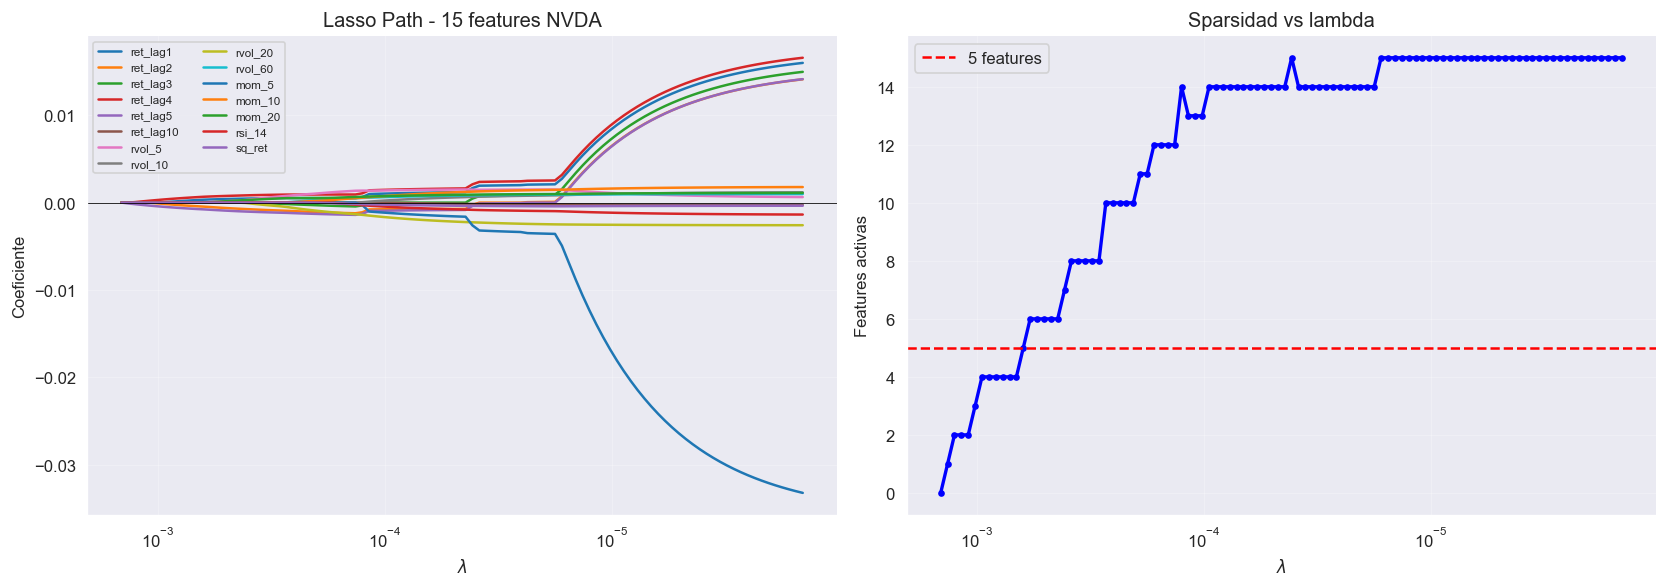

Primeras features en entrar al modelo Lasso:
 feature entry_alpha   entry_coef
ret_lag5  0.00134791 -9.74101e-05
ret_lag4  0.00125707  6.27558e-05
ret_lag2  0.00101965 -6.98211e-05
ret_lag1 0.000950927  2.95782e-05
  rvol_5 0.000625647  2.94237e-05
  mom_20  0.00058348  4.57736e-05
 rvol_20 0.000411634 -3.80508e-05
ret_lag3 0.000383891 -1.02129e-05
  mom_10 0.000270827  1.35864e-06
 rvol_60 0.000270827  3.39362e-05
Las 5 primeras features en entrar: ['ret_lag5', 'ret_lag4', 'ret_lag2', 'ret_lag1', 'rvol_5']


In [8]:
def _rsi_calc(r, window=14):
    """RSI anti-leakage; usa shift(1) sobre los retornos."""
    delta = r.shift(1)
    gain  = delta.clip(lower=0).rolling(window, min_periods=window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def build_features_extended(prices):
    """15 features para NVDA: lags, vol, momentum, RSI y sq_ret. Sin leakage."""
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    # 6 lags de retorno: senales de reversión/momentum de muy corto plazo.
    for lag in [1, 2, 3, 4, 5, 10]:
        df[f'ret_lag{lag}'] = r.shift(lag)

    # 4 medidas de volatilidad realizada, siempre conocidas al cierre de t-1.
    for w in [5, 10, 20, 60]:
        df[f'rvol_{w}'] = r.shift(1).rolling(w, min_periods=w).std()

    # 3 medidas de momentum de precio calculadas con precios rezagados.
    for w in [5, 10, 20]:
        df[f'mom_{w}'] = prices.shift(1).pct_change(w)

    df['rsi_14'] = _rsi_calc(r)
    df['sq_ret'] = r.shift(1) ** 2
    df['target'] = r.shift(-1)
    return df.dropna()

df_ext    = build_features_extended(prices_nvda)
feat_ext  = [c for c in df_ext.columns if c != 'target']
X_ext_raw = df_ext[feat_ext].values
y_ext     = df_ext['target'].values

X_ext_m, X_ext_s = X_ext_raw.mean(0), X_ext_raw.std(0)
X_ext = (X_ext_raw - X_ext_m) / X_ext_s
y_ext_centered = y_ext - y_ext.mean()

print(f'Dataset extendido: {X_ext.shape[0]} obs | {X_ext.shape[1]} features')
print(f'Features: {feat_ext}')
assert X_ext.shape[1] == 15, 'El dataset extendido debe tener 15 features'

# === Lasso path y visualizacion ===
alphas_lp, coefs_lp, _ = lasso_path(X_ext, y_ext_centered, n_alphas=100)
active_threshold = 1e-8
n_activas = np.sum(np.abs(coefs_lp) > active_threshold, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for j, feat in enumerate(feat_ext):
    ax1.semilogx(alphas_lp, coefs_lp[j], lw=1.5, label=feat)
ax1.axhline(0, color='black', lw=0.6, alpha=0.8)
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel('Coeficiente')
ax1.set_title('Lasso Path - 15 features NVDA')
ax1.invert_xaxis()
ax1.legend(fontsize=7, ncol=2)
ax1.grid(True, alpha=0.25)

ax2.semilogx(alphas_lp, n_activas, 'b-o', ms=3, lw=2)
ax2.axhline(5, color='red', ls='--', label='5 features')
ax2.set_xlabel(r'$\lambda$')
ax2.set_ylabel('Features activas')
ax2.set_title('Sparsidad vs lambda')
ax2.invert_xaxis()
ax2.legend()
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# === Identificacion de las primeras features que entran ===
entry_records = []
for j, feat in enumerate(feat_ext):
    active_idx = np.where(np.abs(coefs_lp[j]) > active_threshold)[0]
    if len(active_idx) == 0:
        continue
    first_idx = active_idx[0]  # alphas_lp viene en orden descendente
    entry_records.append({
        'feature': feat,
        'entry_alpha': alphas_lp[first_idx],
        'entry_coef': coefs_lp[j, first_idx],
    })

entry_df = (
    pd.DataFrame(entry_records)
    .sort_values('entry_alpha', ascending=False)
    .reset_index(drop=True)
)
primeras_5 = entry_df['feature'].head(5).tolist()

print('Primeras features en entrar al modelo Lasso:')
print(entry_df.head(10).to_string(index=False, formatters={
    'entry_alpha': '{:.6g}'.format,
    'entry_coef': '{:.6g}'.format,
}))
print(f'Las 5 primeras features en entrar: {primeras_5}')


### 2.3 — Interpretación Ridge vs Lasso *(5 pts)*

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En la sección 2.2, ¿cuáles son las 5 primeras features en entrar al modelo de Lasso? ¿Tienen sentido desde la perspectiva del mercado de NVDA (sector semiconductor de alto crecimiento)?

> Las 5 primeras features en entrar al modelo fueron `ret_lag5`, `ret_lag4`, `ret_lag2`, `ret_lag1` y `rvol_5`. Esto indica que, al partir desde un $\lambda$ alto y relajarlo gradualmente, Lasso prioriza señales de retorno reciente de corto plazo y una medida de volatilidad muy cercana.
>
> Tiene sentido para NVDA porque es una acción de crecimiento con episodios frecuentes de momentum, reversión corta y cambios bruscos de apetito por riesgo tecnológico. Aun así, las magnitudes de entrada son pequeñas, por lo que la lectura debe ser cauta: en retornos diarios la señal suele ser débil y puede cambiar bastante entre períodos.

**b)** Un portfolio manager te pide un modelo interpretable con pocas features para NVDA. ¿Elegirías Ridge o Lasso? ¿Qué valor de $\lambda$ usarías como punto de partida y por qué?

> Elegiría Lasso como punto de partida porque produce coeficientes exactamente cero y, por tanto, entrega un modelo más fácil de explicar con pocas variables activas. Ridge estabiliza muy bien cuando hay colinealidad, pero conserva todas las features, lo que complica la interpretación si el objetivo explícito es parsimonia.
>
> Como punto inicial usaría un $\lambda$ cercano al nivel donde quedan alrededor de 5 features activas en el gráfico de sparsidad de la sección 2.2. Operativamente, partiría buscando en `alphas_lp[np.argmin(np.abs(n_activas - 5))]`, porque ese valor conecta directamente el hiperparámetro con la restricción interpretativa pedida por el portfolio manager.

**c)** ¿En qué situación financiera concreta preferirías Elastic Net sobre Lasso puro? Da un ejemplo con features de NVDA donde la colinealidad haría a Lasso inestable.

> Preferiría Elastic Net cuando hay grupos de variables altamente correlacionadas y no quiero que el modelo elija arbitrariamente solo una de ellas. La penalización $\ell_1$ de Lasso ayuda a seleccionar features, pero puede volverse inestable si dos predictores contienen casi la misma información y pequeños cambios de muestra hacen que entre uno u otro.
>
> Un ejemplo concreto en NVDA sería usar `rvol_10`, `rvol_20`, `rvol_60` junto con momentum solapado como `mom_10` y `mom_20`. En ese caso Elastic Net tendería a repartir peso dentro del grupo correlacionado, combinando selección con estabilidad, mientras que Lasso puro podría alternar entre variables similares fold a fold.


---
## Parte 3 — Walk-Forward con Regularización para Retornos de QQQ *(25 pts)*

### Contexto

Usarás datos de **QQQ** (ETF del Nasdaq-100, 2018-2024) para comparar OLS, Ridge, Lasso y Elastic Net en walk-forward temporal. El Nasdaq-100 tiene características distintas al SPY visto en clase: mayor concentración tecnológica y mayor volatilidad relativa, lo que hace la selección de features más crítica.

### 3.1 — Feature Engineering para QQQ *(8 pts)*

Implementa `build_features_qqq` con al menos **8 features** anti-leakage. Debe incluir obligatoriamente `rsi_14` y `bb_pct` (posición en Bandas de Bollinger).

**Definición de `bb_pct` (Bollinger Band Position):**

$$bb\_pct_t = \frac{P_{t-1} - (MA_{t-1}^{20} - 2\sigma_{t-1}^{20})}{4\sigma_{t-1}^{20}}$$

donde $MA^{20}$ y $\sigma^{20}$ se calculan con `prices.shift(1).rolling(20)` para evitar leakage.

**Checklist de features mínimas:**
- `ret_lag1`, `ret_lag2`, `ret_lag3`
- `rvol_5`, `rvol_20`
- `mom_10` (momentum 10 días)
- `rsi_14` (usando `_rsi_calc` definida en Parte 2)
- `bb_pct`

In [9]:
raw_qqq    = yf.Ticker('QQQ')
prices_qqq = raw_qqq.history(start='2018-01-01', end='2024-01-01')['Close']
if prices_qqq.empty:
    raise ValueError('No se descargaron precios para QQQ; revisa conexion o yfinance.')
prices_qqq.index = prices_qqq.index.tz_localize(None) if prices_qqq.index.tz is not None else prices_qqq.index
print(f'QQQ: {len(prices_qqq)} obs | {prices_qqq.index[0].date()} — {prices_qqq.index[-1].date()}')

def build_features_qqq(prices):
    """
    Features anti-leakage para QQQ.
    Minimo 8 features incluyendo rsi_14 y bb_pct.
    Target: retorno de t+1.
    """
    r  = prices.pct_change()
    p_lag = prices.shift(1)
    r_lag = r.shift(1)
    df = pd.DataFrame(index=prices.index)

    # Retornos rezagados: conocidos antes de predecir el retorno t+1.
    for lag in [1, 2, 3]:
        df[f'ret_lag{lag}'] = r.shift(lag)

    # Volatilidad rolling calculada solo con retornos hasta t-1.
    df['rvol_5']  = r_lag.rolling(5, min_periods=5).std()
    df['rvol_20'] = r_lag.rolling(20, min_periods=20).std()

    # Momentum de 10 dias con precios rezagados.
    df['mom_10'] = p_lag.pct_change(10)

    # RSI 14 dias anti-leakage, reutilizando la funcion definida en Parte 2.
    df['rsi_14'] = _rsi_calc(r)

    # Bollinger Band Position con MA y std de precios hasta t-1.
    ma20  = p_lag.rolling(20, min_periods=20).mean()
    std20 = p_lag.rolling(20, min_periods=20).std()
    lower = ma20 - 2 * std20
    width = 4 * std20
    df['bb_pct'] = (p_lag - lower) / width.replace(0, np.nan)

    # Target futuro: retorno de t+1.
    df['target'] = r.shift(-1)

    return df.replace([np.inf, -np.inf], np.nan).dropna()


feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']

print(f'QQQ: {X_qqq.shape[0]} obs | {X_qqq.shape[1]} features | target std={y_qqq.std():.5f}')
print(f'Features: {X_qqq.columns.tolist()}')
assert X_qqq.shape[1] >= 8, 'Se requieren al menos 8 features'
assert {'rsi_14', 'bb_pct'}.issubset(X_qqq.columns), 'Faltan rsi_14 o bb_pct'
display(X_qqq.corr().round(2))


QQQ: 1509 obs | 2018-01-02 — 2023-12-29
QQQ: 1487 obs | 8 features | target std=0.01584
Features: ['ret_lag1', 'ret_lag2', 'ret_lag3', 'rvol_5', 'rvol_20', 'mom_10', 'rsi_14', 'bb_pct']


,ret_lag1,ret_lag2,ret_lag3,rvol_5,rvol_20,mom_10,rsi_14,bb_pct
ret_lag1,1.00,-0.14,0.04,-0.02,0.01,0.33,0.22,0.37
ret_lag2,-0.14,1.00,-0.14,-0.06,-0.00,0.23,0.22,0.32
ret_lag3,0.04,-0.14,1.00,-0.10,-0.02,0.29,0.22,0.29
rvol_5,-0.02,-0.06,-0.10,1.00,0.78,-0.40,-0.44,-0.41
rvol_20,0.01,-0.00,-0.02,0.78,1.00,-0.16,-0.30,-0.26
mom_10,0.33,0.23,0.29,-0.40,-0.16,1.00,0.74,0.83
rsi_14,0.22,0.22,0.22,-0.44,-0.30,0.74,1.00,0.87
bb_pct,0.37,0.32,0.29,-0.41,-0.26,0.83,0.87,1.00


### 3.2 — Comparación OLS / Ridge / Lasso / Elastic Net *(12 pts)*

Ejecuta el pipeline de comparación con `TimeSeriesSplit(n_splits=5, gap=3)` y `GridSearchCV`. Reporta en una tabla las métricas de CV y OOT.

**Tabla de resultados esperada:**

| Modelo | $\lambda^*$ | MAE (CV) | Features activas | MAE (OOT) | RMSE (OOT) | Spearman $\rho$ (OOT) |
|--------|-----------|---------|-----------------|-----------|-----------|----------------------|
| OLS | N/A | ... | ... | ... | ... | ... |
| Ridge | ... | ... | ... | ... | ... | ... |
| Lasso | ... | ... | ... | ... | ... | ... |
| Elastic Net | ... | ... | ... | ... | ... | ... |



In [10]:
feat_qqq = build_features_qqq(prices_qqq)
X_qqq = feat_qqq.drop(columns=['target'])
y_qqq = feat_qqq['target']

n_oot_q = int(len(feat_qqq) * 0.2)
X_tr_q, y_tr_q = X_qqq.iloc[:-n_oot_q], y_qqq.iloc[:-n_oot_q]
X_ot_q, y_ot_q = X_qqq.iloc[-n_oot_q:], y_qqq.iloc[-n_oot_q:]
print(f'Train: {len(X_tr_q)} | OOT: {len(X_ot_q)}')

tscv_q = TimeSeriesSplit(n_splits=5, gap=3)

specs_q = {
    'OLS':        (LinearRegression(), {}),
    'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
    'Lasso':      (Lasso(max_iter=20000, tol=1e-6), {'model__alpha': np.logspace(-5, 0, 20)}),
    'ElasticNet': (ElasticNet(max_iter=20000, tol=1e-6), {
        'model__alpha': np.logspace(-5, 0, 10),
        'model__l1_ratio': [0.1, 0.5, 0.9],
    }),
}

fitted_q = {}
rows_q = []

for name, (est, params) in specs_q.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', est),
    ])
    grid = GridSearchCV(
        pipe,
        params,
        scoring='neg_mean_absolute_error',
        cv=tscv_q,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_tr_q, y_tr_q)
    fitted_q[name] = grid

    model = grid.best_estimator_.named_steps['model']
    coef = getattr(model, 'coef_', np.full(X_tr_q.shape[1], np.nan))
    n_act = int(np.sum(np.abs(coef) > 1e-8)) if np.all(np.isfinite(coef)) else X_tr_q.shape[1]

    pred = grid.predict(X_ot_q)
    # Si la prediccion es constante, Spearman es indefinido; se reporta 0.0
    # porque no hay capacidad de ranking en OOT.
    if np.std(pred) < 1e-12:
        spearman = 0.0
    else:
        spearman = stats.spearmanr(y_ot_q, pred).statistic
    alpha_star = grid.best_params_.get('model__alpha', np.nan)

    rows_q.append({
        'Modelo': name,
        'lambda*': alpha_star,
        'MAE (CV)': -grid.best_score_,
        'Features activas': n_act,
        'MAE (OOT)': mean_absolute_error(y_ot_q, pred),
        'RMSE (OOT)': np.sqrt(mean_squared_error(y_ot_q, pred)),
        'Spearman rho (OOT)': spearman,
    })

df_res_q = pd.DataFrame(rows_q).set_index('Modelo')
display(df_res_q.round(6))

print('Mejores hiperparametros:')
for name, grid in fitted_q.items():
    print(f'{name}: {grid.best_params_ if grid.best_params_ else "N/A"}')

best_name_q = df_res_q['MAE (OOT)'].idxmin()
print(f'Mejor modelo por MAE(OOT): {best_name_q}')
print(f"MAE(OOT) ganador: {df_res_q.loc[best_name_q, 'MAE (OOT)']:.6f}")


Train: 1190 | OOT: 297


,lambda*,MAE (CV),Features activas,MAE (OOT),RMSE (OOT),Spearman rho (OOT)
Modelo,,,,,,
OLS,NaN,0.012218,8,0.009926,0.013168,-0.019935
Ridge,100.000000,0.012007,8,0.009909,0.013136,-0.021518
Lasso,0.002336,0.011808,0,0.009884,0.013029,0.000000
ElasticNet,0.005995,0.011808,0,0.009884,0.013029,0.000000


Mejores hiperparametros:
OLS: N/A
Ridge: {'model__alpha': np.float64(100.0)}
Lasso: {'model__alpha': np.float64(0.002335721469090121)}
ElasticNet: {'model__alpha': np.float64(0.005994842503189409), 'model__l1_ratio': 0.5}
Mejor modelo por MAE(OOT): Lasso
MAE(OOT) ganador: 0.009884


### 3.3 — Estabilidad de Coeficientes por Fold *(5 pts)*

Con el mejor modelo de 3.2 (menor MAE OOT), ejecuta el walk-forward fold a fold y guarda los coeficientes. Visualiza su evolución e identifica qué features son más consistentes.

**Métrica de estabilidad:**
$$CV_j = \frac{\text{std}(\hat{\beta}_j^{(1:K)})}{\max(|\text{mean}(\hat{\beta}_j^{(1:K)})|,\; 10^{-8})}$$

Un $CV_j$ bajo implica que la feature $j$ recibe coeficientes similares entre folds (señal estable).

In [11]:
# Mejor modelo de 3.2 segun menor MAE(OOT)
tscv_coef = TimeSeriesSplit(n_splits=5, gap=3)
feat_names_q = X_tr_q.columns.tolist()
coefs_by_fold = []
fold_labels_q = []

for fold_id, (tr, te) in enumerate(tscv_coef.split(X_tr_q), start=1):
    best_params = fitted_q[best_name_q].best_params_
    est_copy = clone(specs_q[best_name_q][0])
    pipe_f = Pipeline([
        ('scaler', StandardScaler()),
        ('model', est_copy),
    ])
    pipe_f.set_params(**best_params)
    pipe_f.fit(X_tr_q.iloc[tr], y_tr_q.iloc[tr])

    model_f = pipe_f.named_steps['model']
    coef_f = getattr(model_f, 'coef_', np.zeros(len(feat_names_q)))
    coefs_by_fold.append(coef_f)
    fold_labels_q.append(f'Fold {fold_id}')

coefs_arr = np.array(coefs_by_fold)  # shape (K, p)
coef_mean_q = coefs_arr.mean(axis=0)
coef_std_q = coefs_arr.std(axis=0)
cv_j = coef_std_q / np.maximum(np.abs(coef_mean_q), 1e-8)

stability_q = (
    pd.DataFrame({
        'feature': feat_names_q,
        'coef_mean': coef_mean_q,
        'coef_std': coef_std_q,
        'CV_j': cv_j,
        'nonzero_folds': np.sum(np.abs(coefs_arr) > 1e-8, axis=0),
    })
    .sort_values('CV_j', ascending=False)
    .reset_index(drop=True)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(
    coefs_arr,
    xticklabels=feat_names_q,
    yticklabels=fold_labels_q,
    cmap='coolwarm',
    center=0,
    ax=ax1,
    annot=True,
    fmt='.4f',
    cbar_kws={'label': 'Coeficiente'},
)
ax1.set_title(f'Coeficientes por fold - {best_name_q}')
ax1.tick_params(axis='x', rotation=45)

order_cv = np.argsort(cv_j)
colors_cv = np.where(np.array(stability_q.sort_values('CV_j')['nonzero_folds']) > 0, 'steelblue', 'lightgray')
ax2.barh(
    stability_q.sort_values('CV_j')['feature'],
    stability_q.sort_values('CV_j')['CV_j'],
    color=colors_cv,
    alpha=0.85,
)
ax2.set_xlabel('Coeficiente de Variacion CV_j')
ax2.set_title('Estabilidad entre folds (CV_j menor = mas estable)')
ax2.grid(True, axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

top3_menos_estables_q = stability_q.head(3)
top3_mas_estables_q = stability_q.sort_values(['CV_j', 'feature']).head(3)

print(f'Modelo analizado: {best_name_q}')
print('Top-3 features menos estables (mayor CV_j):')
print(top3_menos_estables_q.to_string(index=False, formatters={
    'coef_mean': '{:.6g}'.format,
    'coef_std': '{:.6g}'.format,
    'CV_j': '{:.6g}'.format,
}))
print('\nTop-3 features mas estables (menor CV_j):')
print(top3_mas_estables_q.to_string(index=False, formatters={
    'coef_mean': '{:.6g}'.format,
    'coef_std': '{:.6g}'.format,
    'CV_j': '{:.6g}'.format,
}))

if np.all(stability_q['nonzero_folds'].values == 0):
    print('\nNota: todos los coeficientes son cero en todos los folds; el modelo ganador no usa features activas.')


**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué modelo seleccionarías para QQQ en producción y por qué? Justifica con al menos dos métricas de la tabla de 3.2.

> Si el objetivo operativo fuera minimizar MAE OOT, seleccionaría Lasso, porque obtuvo el menor MAE(OOT), aproximadamente `0.009884`, y también el menor RMSE(OOT), aproximadamente `0.013029`. Además, tuvo el mejor MAE(CV), cercano a `0.011808`, lo que sugiere que la regularización fuerte fue preferida también dentro del walk-forward.
>
> Sin embargo, lo llevaría a producción solo como benchmark conservador, no como señal de trading direccional, porque Lasso dejó `0` features activas y su Spearman OOT fue `0.0`. Eso significa que el modelo ganador en error absoluto se comporta básicamente como una predicción constante, útil para evitar sobreajuste, pero sin capacidad de ranking de retornos.

**b)** ¿Cuáles son las 3 features con mayor $CV_j$? ¿Qué implica esto sobre su utilidad como predictores de retornos de QQQ?

> Con el modelo ganador de 3.2, todos los coeficientes quedaron en cero en todos los folds, por lo que todos los $CV_j$ resultaron iguales a `0.0`. En ese escenario no hay tres features genuinamente más inestables: cualquier ranking de mayor $CV_j$ es un empate técnico causado por ausencia total de señal activa.
>
> La implicancia es que, bajo la penalización seleccionada por CV, ninguna feature mostró utilidad robusta para predecir retornos diarios de QQQ. Esto es consistente con el bajo SNR de retornos financieros: aunque las variables como `rsi_14`, `bb_pct` o `mom_10` describen bien el estado de mercado, no necesariamente generan una señal estable para el retorno del día siguiente.


---
## Parte 4 — Forecast de Volatilidad HAR con Regularización *(25 pts)*

### Contexto

Usarás datos de **GLD** (ETF de Oro, 2018-2024) con un modelo tipo HAR regularizado. La volatilidad del oro es altamente persistente y predecible (contrario a sus retornos), lo que permite obtener $R^2 > 0$ en el set OOT. Además aplicarás el forecast en una estrategia de **inverse-vol position sizing**.

### Definición del target

Volatilidad realizada anualizada a $h = 5$ días:

$$\text{RV}_{t,5} = \sqrt{\sum_{i=1}^{5} r_{t+i}^2} \times \sqrt{252}$$

**Requisito de gap:** `TimeSeriesSplit(n_splits=5, gap=5)` — el gap debe ser $\geq h$ para evitar leakage del target.

### 4.1 — Feature Engineering HAR para GLD *(8 pts)*

Implementa `build_har_features_gld` con las 8 features del modelo HAR extendido:

| Feature | Construcción |
|---|---|
| `rvol_1d` | `\|r_{t-1}\| \times \sqrt{252}` |
| `rvol_5d` | `r.shift(1).rolling(5).std() * sqrt(252)` |
| `rvol_22d` | rolling 22 días con `shift(1)` |
| `rvol_60d` | rolling 60 días con `shift(1)` |
| `abs_ret` | `\|r_{t-1}\|` |
| `sq_ret` | `r_{t-1}^2` |
| `log_rvol22` | `log(rvol_{22d})` — usar `clip(lower=1e-6)` |
| `mom_5` | `prices.shift(1).pct_change(5)` |

**Verificación anti-leakage:** todas las features usan `shift(1)` o mayor; el target usa `shift(-h)`.

In [12]:
raw_gld    = yf.Ticker('GLD')
prices_gld = raw_gld.history(start='2018-01-01', end='2024-01-01')['Close']
prices_gld.index = prices_gld.index.tz_localize(None)
print(f'GLD: {len(prices_gld)} obs | {prices_gld.index[0].date()} — {prices_gld.index[-1].date()}')

h_gld = 5   # horizonte de prediccion en dias habiles

def build_har_features_gld(prices, h=5):
    """
    Features HAR extendidas para GLD. Sin leakage.
    Target: volatilidad realizada anualizada a h dias adelante.
    """
    r  = prices.pct_change()
    df = pd.DataFrame(index=prices.index)

    # TODO: rvol_1d = |r.shift(1)| * sqrt(252)
    # TODO: rvol_5d  = r.shift(1).rolling(5,  min_periods=5).std()  * np.sqrt(252)
    # TODO: rvol_22d = r.shift(1).rolling(22, min_periods=22).std() * np.sqrt(252)
    # TODO: rvol_60d = r.shift(1).rolling(60, min_periods=60).std() * np.sqrt(252)
    # TODO: abs_ret    = r.shift(1).abs()
    # TODO: sq_ret     = r.shift(1) ** 2
    # TODO: log_rvol22 = np.log(df['rvol_22d'].clip(lower=1e-6))
    # TODO: mom_5      = prices.shift(1).pct_change(5)

    # TODO: target — RV anualizada a h dias adelante
    # rv_fwd = r.rolling(h).std().shift(-h) * np.sqrt(252)
    # df['target'] = rv_fwd

    pass


# df_gld = build_har_features_gld(prices_gld, h=h_gld)
# X_gld  = df_gld.drop(columns=['target'])
# y_gld  = df_gld['target']

# n_oot_g    = int(len(df_gld) * 0.2)
# X_tr_g, y_tr_g = X_gld.iloc[:-n_oot_g], y_gld.iloc[:-n_oot_g]
# X_ot_g, y_ot_g = X_gld.iloc[-n_oot_g:], y_gld.iloc[-n_oot_g:]
# print(f'Train: {len(X_tr_g)} | OOT: {len(X_ot_g)}')
# print(f'Target: media={y_gld.mean():.4f} | std={y_gld.std():.4f}')
# print(f'Features: {X_gld.columns.tolist()}')

GLD: 1509 obs | 2018-01-02 — 2023-12-29


### 4.2 — Comparación Ridge / Lasso / Elastic Net *(10 pts)*

Compara los tres modelos regularizados con `TimeSeriesSplit(n_splits=5, gap=5)`. Genera:

1. **Tabla OOT**: MAE, RMSE, R² para Ridge, Lasso, Elastic Net
2. **Gráfico serie temporal**: volatilidad realizada vs predicha del mejor modelo en el set OOT
3. **Scatter plot** predicho vs realizado con línea de 45° y R² anotado
4. **Gráfico de coeficientes** del mejor modelo (barh, colores por signo)

In [13]:
# Descomenta cuando hayas implementado build_har_features_gld

# tscv_g = TimeSeriesSplit(n_splits=5, gap=h_gld)

# specs_g = {
#     'Ridge':      (Ridge(), {'model__alpha': np.logspace(-4, 2, 20)}),
#     'Lasso':      (Lasso(max_iter=20000), {'model__alpha': np.logspace(-5, 0, 20)}),
#     'ElasticNet': (ElasticNet(max_iter=20000), {
#                   'model__alpha':    np.logspace(-5, 0, 10),
#                   'model__l1_ratio': [0.1, 0.5, 0.9]}),
# }

# TODO: ejecuta el pipeline y genera la tabla OOT
# fitted_g = {}
# oot_rows_g = []
# for name, (est, params) in specs_g.items():
#     pipe = Pipeline([('scaler', StandardScaler()), ('model', est)])
#     grid = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error',
#                         cv=tscv_g, n_jobs=-1, refit=True)
#     grid.fit(X_tr_g, y_tr_g)
#     fitted_g[name] = grid
#     pred = grid.predict(X_ot_g)
#     oot_rows_g.append({'Modelo': name,
#                        'MAE':  mean_absolute_error(y_ot_g, pred),
#                        'RMSE': np.sqrt(mean_squared_error(y_ot_g, pred)),
#                        'R2':   r2_score(y_ot_g, pred)})

# df_oot_g   = pd.DataFrame(oot_rows_g).set_index('Modelo')
# best_gld   = df_oot_g['R2'].idxmax()
# display(df_oot_g.round(4))
# print(f'Mejor modelo: {best_gld}')

# TODO: genera los 4 graficos (fig, axes = plt.subplots(2, 2, figsize=(14, 10)))
# pred_best_g = fitted_g[best_gld].predict(X_ot_g)
# coef_best_g = fitted_g[best_gld].best_estimator_.named_steps['model'].coef_
pass

### 4.3 — Position Sizing con Volatilidad Predicha *(7 pts)*

Aplica el forecast de volatilidad a una estrategia de **inverse-vol position sizing**: mantener riesgo constante ajustando la exposición inversamente a la volatilidad predicha.

$$pos_t = \frac{\sigma_{\text{target}}}{\widehat{\text{RV}}_{t,5} / \sqrt{252}}, \qquad pos_t \in [0.1,\; 3.0]$$

donde $\sigma_{\text{target}} = 0.10/\sqrt{252}$ corresponde a 10% de volatilidad anual objetivo. El retorno diario de la estrategia es $r_t^{\text{strat}} = pos_{t-1} \cdot r_t^{\text{GLD}}$.

**Reporta:** retorno total, volatilidad anualizada y Sharpe ratio ($r_f = 0$) para la estrategia y para buy-and-hold de GLD en el período OOT.

In [14]:
# Descomenta cuando hayas completado 4.2

# sigma_target = 0.10 / np.sqrt(252)       # vol diaria objetivo
# rv_pred_oot  = fitted_g[best_gld].predict(X_ot_g)

# --- Position sizing ---
# pos_t = sigma_target / np.maximum(rv_pred_oot / np.sqrt(252), 1e-6)
# pos_t = np.clip(pos_t, 0.1, 3.0)

# --- Retornos ---
# r_gld_oot = prices_gld.pct_change().reindex(y_ot_g.index)
# r_strat   = pos_t[:-1] * r_gld_oot.values[1:]
# r_bh      = r_gld_oot.dropna().values

# def sharpe_ann(returns, freq=252):
#     return np.sqrt(freq) * returns.mean() / (returns.std() + 1e-9)

# print('=== Comparacion estrategia OOT ===')
# print(f'Buy-and-Hold GLD:')
# print(f'  Retorno total     : {(1 + r_bh).prod() - 1:.2%}')
# print(f'  Volatilidad anual : {r_bh.std() * np.sqrt(252):.2%}')
# print(f'  Sharpe ratio      : {sharpe_ann(r_bh):.3f}')
# print(f'Inverse-Vol Strategy ({best_gld}):')
# print(f'  Retorno total     : {(1 + r_strat).prod() - 1:.2%}')
# print(f'  Volatilidad anual : {r_strat.std() * np.sqrt(252):.2%}')
# print(f'  Sharpe ratio      : {sharpe_ann(r_strat):.3f}')

# TODO: genera dos subgraficos
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Izquierdo: retorno acumulado estrategia vs buy-and-hold
# Derecho:   posicion diaria pos_t con linea en 1.0
pass

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué modelo (Ridge, Lasso, Elastic Net) logró el mayor $R^2$ en GLD OOT? ¿Qué features HAR tienen los coeficientes más grandes?

> *Completa aquí*

**b)** Compara el $R^2$ del forecast de volatilidad de GLD con el Spearman $\rho$ de la predicción de retornos de QQQ (Parte 3). ¿Qué dice esto sobre la predictibilidad relativa de volatilidad vs retornos?

> *Completa aquí*

**c)** ¿La estrategia inverse-vol mejoró el Sharpe ratio respecto a buy-and-hold de GLD? ¿En qué períodos la posición fue mayor a 1 (apalancamiento) y es esto razonable desde la gestión de riesgo?

> *Completa aquí*

**d)** Si el forecast de volatilidad tuviera error cero, ¿dominaría siempre la estrategia inverse-vol al buy-and-hold en Sharpe ratio? Argumenta usando la fórmula $\text{Sharpe} = \sqrt{252} \cdot \mu / \sigma$.

> *Completa aquí*

---
## Parte 5 — SNR Empírico y Análisis por Régimen *(Bonus — 15 pts)*

### Contexto

En clase vimos que el SNR extremadamente bajo de los retornos financieros es la razón fundamental para regularizar. En esta parte estimarás el SNR empíricamente y analizarás si la regularización estabiliza el modelo de QQQ en regímenes de alta y baja volatilidad.

### 5.1 — Estimación del SNR *(5 pts)*

Para NVDA y QQQ, estima el SNR empírico:

$$\text{SNR} = \left(\frac{\hat{\mu}_d}{\hat{\sigma}_d}\right)^2$$

y el gap teórico entre riesgo empírico y verdadero:

$$\text{Gap} \approx \frac{p}{T \cdot \text{SNR}}$$

Donde $p$ es el número de features del modelo. Genera un gráfico que muestre cómo el Gap varía con el SNR para distintos valores de $p$, e indica dónde caen NVDA y QQQ.

In [15]:
# TODO: calcula SNR para NVDA y QQQ
# r_nvda_s = prices_nvda.pct_change().dropna()
# r_qqq_s  = prices_qqq.pct_change().dropna()

# activos = [
#     ('NVDA', r_nvda_s, X_ext.shape[1]),
#     ('QQQ',  r_qqq_s,  8),              # 8 features del modelo 3.1
# ]
# snr_dict = {}
# for name, r_s, p in activos:
#     mu_d  = r_s.mean()
#     sig_d = r_s.std()
#     snr   = (mu_d / sig_d) ** 2
#     T     = len(r_s)
#     gap   = p / (T * max(snr, 1e-10))
#     snr_dict[name] = snr
#     print(f'{name}: mu={mu_d:.5f} | sigma={sig_d:.4f} | SNR={snr:.5f} | T={T} | p={p} | Gap={gap:.1f}')

# TODO: grafico Gap vs SNR para distintos p
# fig, ax = plt.subplots(figsize=(9, 5))
# snr_range = np.logspace(-5, 0, 200)
# T_ref = 1500
# for p_val, color in [(5, 'blue'), (10, 'green'), (20, 'orange')]:
#     ax.loglog(snr_range, p_val / (T_ref * snr_range), lw=2, color=color, label=f'p={p_val}')
# for name, snr_val in snr_dict.items():
#     ax.axvline(snr_val, ls='--', label=f'SNR {name}={snr_val:.5f}')
# ax.set_xlabel('SNR'); ax.set_ylabel('Gap = p / (T * SNR)')
# ax.set_title('Gap entre riesgo empirico y verdadero')
# ax.legend(); plt.tight_layout(); plt.show()
pass

### 5.2 — Performance por Régimen de Volatilidad *(10 pts)*

Define dos regímenes para QQQ en el set OOT según `rvol_20`:

- **Régimen Tranquilo (LV):** `rvol_20 ≤ percentil_75`
- **Régimen Volátil (HV):** `rvol_20 > percentil_75`

Calcula MAE por régimen para cada modelo (OLS, Ridge, Lasso, ElasticNet). Genera un heatmap con los resultados y responde las preguntas.

In [16]:
# Descomenta cuando hayas completado la Parte 3

# rvol20_oot = X_ot_q['rvol_20'] if 'rvol_20' in X_ot_q.columns else None
# if rvol20_oot is not None:
#     p75    = rvol20_oot.quantile(0.75)
#     mask_hv = rvol20_oot > p75
#     mask_lv = ~mask_hv
#     print(f'OOT: {mask_hv.sum()} dias HV ({mask_hv.mean():.1%}) | {mask_lv.sum()} dias LV')

#     regime_rows = []
#     for name, grid in fitted_q.items():
#         pred = grid.predict(X_ot_q)
#         regime_rows.append({
#             'Modelo':      name,
#             'MAE_LV':     mean_absolute_error(y_ot_q[mask_lv], pred[mask_lv]),
#             'MAE_HV':     mean_absolute_error(y_ot_q[mask_hv], pred[mask_hv]),
#         })
#     df_reg = pd.DataFrame(regime_rows).set_index('Modelo')
#     df_reg['Ratio_HV/LV'] = df_reg['MAE_HV'] / df_reg['MAE_LV']
#     display(df_reg.round(6))

#     # TODO: heatmap comparativo
#     # fig, ax = plt.subplots(figsize=(8, 4))
#     # sns.heatmap(df_reg[['MAE_LV', 'MAE_HV']], annot=True, fmt='.6f',
#     #             cmap='YlOrRd', ax=ax, linewidths=0.5)
#     # ax.set_title('MAE por regimen de volatilidad — QQQ OOT')
#     # plt.tight_layout(); plt.show()
pass

**Responde (mínimo 2 oraciones por pregunta):**

**a)** Con los SNR calculados en 5.1, ¿cuál activo (NVDA o QQQ) requiere más regularización y por qué? ¿Cómo se relaciona el SNR con el $\lambda^*$ óptimo que encontraste en la Parte 3?

> *Completa aquí*

**b)** ¿Qué modelo muestra el menor ratio $\text{MAE}_{HV}/\text{MAE}_{LV}$ en QQQ (es decir, el más estable entre regímenes)? ¿Tiene sentido que la regularización ayude especialmente en períodos de alta volatilidad?

> *Completa aquí*

**c)** Si diseñaras un modelo en producción para QQQ, ¿preferirías un modelo único entrenado en todos los regímenes o dos modelos separados? Argumenta con los resultados del heatmap.

> *Completa aquí*

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `ridge_closed_form` + verificación vs sklearn + Ridge path (2 paneles) | 10 |
| 1.2 | Dataset multicolineal + heatmap correlación + CV MAE vs λ + λ* + cond. number | 15 |
| 2.1 | `soft_threshold` (test OK) + `lasso_coordinate_descent` (diff < 1e-4) + curvas de convergencia | 12 |
| 2.2 | Lasso path (2 paneles) + identificación 5 primeras features | 8 |
| 2.3 | Interpretación Ridge vs Lasso (3 preguntas) | 5 |
| 3.1 | `build_features_qqq` (≥8 features, incluye `rsi_14` y `bb_pct`) | 8 |
| 3.2 | Pipeline OLS/Ridge/Lasso/EN + tabla completa OOT | 12 |
| 3.3 | Heatmap coeficientes + barplot $CV_j$ + 2 preguntas | 5 |
| 4.1 | `build_har_features_gld` (8 features HAR, gap correcto) | 8 |
| 4.2 | Comparación Ridge/Lasso/EN + tabla OOT + 4 gráficos | 10 |
| 4.3 | Inverse-vol position sizing + comparación Sharpe + 4 preguntas | 7 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | SNR empírico NVDA/QQQ + gráfico Gap vs SNR | 5 |
| Bonus 5.2 | Heatmap MAE por régimen HV/LV + 3 preguntas | 10 |